In [1]:
import os
os.chdir(r"C:\Users\24649\Documents\bhsr") # change this to the directory that contains the "data" folder
#within the "data" folder, there should be the required npz files. 

import numpy as np
import math
import matplotlib.pyplot as plt

from binary_level_transition_functions import * # or just import find_cf_root, alpha, rg, GNewton 

Boson Mass is: 0.2926837837850054 eV 

BH Mass is: 9.54e-11 solar masses

Omega0 is: 1.72e+09 Hz
gamma is: 1.47e-21 Hz
Eta is: 3.524094122062965e-11
Instablity rate is:3.8090981451512986e-07
Mass is: 1.0694825599594304e+56
z is: 0.4227343070757376
peak frequency is: 1070107542.1721139
clould_mass_ratio is: 0.09282152472845498


NameError: name 'label_fs' is not defined

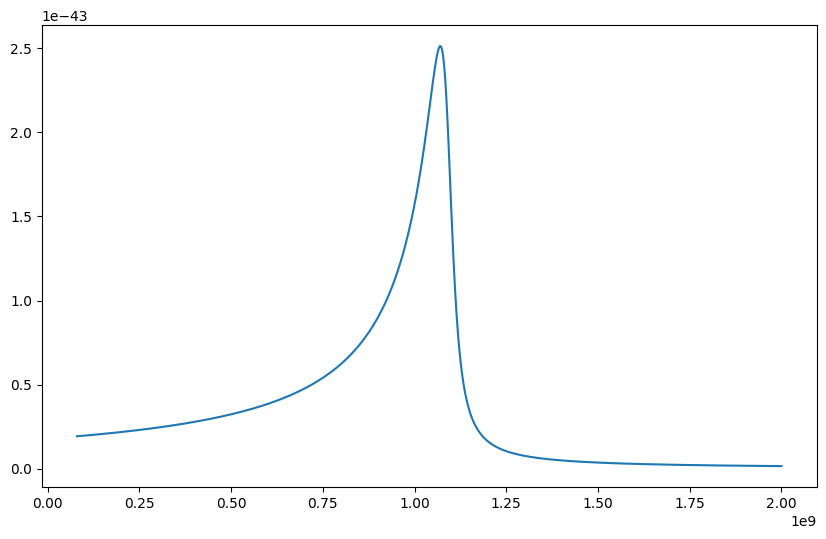

In [3]:
# Mass that goes into the waveform is eV in calculation, but solar mass as input

#=======================================
#Unit Conversion from BHSR
#=======================================
eV_per_kg = 1.782622e-36
mP_in_GeV = 1.220890e19 # GeV
mP_in_eV = 1e9*mP_in_GeV # eV

# Astro constants
Msol_in_kg = 1.99841e30 # kg
Msol_in_eV = Msol_in_kg/eV_per_kg # eV

mP2_in_eVMsol = mP_in_eV*(mP_in_eV/Msol_in_eV) # eV Msol
GNewton = 1/mP2_in_eVMsol # Author of the BHSR code elected to let G have units of eV^-1 Msol^-1, instead of Gev^-2

#--------------------------------------------

M_sol= 0.954e-10 #   
M = 0.954e-10      # BH mass in solar masses
M *= Msol_in_eV #BH Mass in eV#1.1e66 # eV conversion
r      = 10000    # pc
r *=  1.5625e23 # pc in eV^-1
alpha  = 0.21
Mp = 1.220890e28 # for eV
G = 1 / Mp**2 
n=2

l_i, m_i = 1, 1 # for state transitions, initial state
l_f, m_f = 1, -1 # for state transitions, final state


m_boson = alpha/(G*M) # Boson mass in eV

   # choose so that f_c ~ 1e3
q      = 1e-3 # Binary mass ratio
m_i    = 1
m_f    = -1 # Quantum Numbers
eta = eta_parameter(alpha, q, M_sol) #eta    = 5.0e-2      # parameter entering z (or leave None to use z_scaling below)
a = a_tilde_crit(m_i, alpha) #dimensionless spin but we make it always equal to 1
Omega0 = Omega0_binary_natural_unit(m_i, alpha, G, M, n, l_i) # Frequency in eV
gamma = gamma_rate(q, M, Omega0)
Gamma_abs = np.abs(np.imag(find_cf_root(M_sol, a, m_boson, n, l_i, m_f))) * rg(M_sol)/ (G * M)#cfm_bhsr_rates(mbh0, mu_max)   # width |Γ| in Hz (or your freq units)

Omega0_Hz = Omega0*2.417987242e14
f = np.linspace(8e7, 2e9, 100000)


h_of_iota = htilde_plus(
    f / 2.417987242e14, M, r, alpha, Omega0, q, m_i, m_f, eta, Gamma_abs,
    use_z_scaling=False, numerical_qc=False  # set True to use numerical for q_c, set False to use analytical
)
print(f'Boson Mass is: {m_boson} eV \n')
print(f'BH Mass is: {M/Msol_in_eV} solar masses\n')
print(f'Omega0 is: {Omega0*2.417987242e14:.3} Hz')
print(f'gamma is: {gamma:.3} Hz')
print(f'Eta is: {eta}')
print(f'Instablity rate is:{Gamma_abs}')
print(f'Mass is: {M}')
print(f'z is: {z_parameter(eta, 2, gamma)}')
print(f'peak frequency is: {(fc_from_Omega0(Omega0) - 2 * z_parameter(eta, 2, gamma)* Gamma_abs / np.pi) *2.417987242e14}')
print(f'numerical clould_mass_ratio is: {compute_cloud_mass_numerical(alpha, M, m_boson, spin=0.99)/M}')
print(f'analytical clould_mass_ratio is: {q_c(alpha, m_i)}')

iota = np.pi/2
Hf = h_of_iota(iota)


# Plot amplitude
plt.figure(figsize=(10,6))

#plt.semilogy(f, np.abs(Hf)) #change this to plt.plot to restore it to linear to match the mathematica graph

plt.plot(f, np.abs(Hf))


plt.xscale('log')      # keep x-axis logarithmic
#plt.yscale('log')   # linear y-axis

plt.tick_params(axis='both', which='both', labelsize=tick_fs)

plt.grid(True, ls=":")
plt.tight_layout()
plt.show()
